In [11]:
# Cell 1 — Setup + Frozen Configuration
import sys
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import linregress


def find_repo_root(start):
    """Find the repository root from any notebook working directory."""
    for path in (start, *start.parents):
        if (path / "phase1" / "src").is_dir():
            return path
    raise FileNotFoundError("Repository root was not found.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
repo_path = str(REPO_ROOT)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

loader = import_module("phase1.src.dataloader.loader")
lyapunov = import_module("phase1.src.chaos.lyapunov")
load_segmented_session = loader.load_segmented_session
compute_rosenstein_lle = lyapunov.compute_rosenstein_lle
estimate_mean_period = lyapunov.estimate_mean_period
reconstruct_phase_space = lyapunov.reconstruct_phase_space
find_nearest_neighbors = lyapunov.find_nearest_neighbors
compute_divergence_curve = lyapunov.compute_divergence_curve

SESSION = 1
SESSION_FILE = f"sample_{SESSION}.csv"
REPRESENTATION = "processed"
SEGMENTED_DATA_DIR = REPO_ROOT / "phase1" / "segmentated_data" / "dhdata"
WINDOW_DURATIONS_S = (60, 120, 180)
STATE_LABELS = {"Awake": 0, "Drowsy": 1}

M = 8
TAU_S = 0.16
FS = 50.0
TAU_SAMPLES = 8

MAX_FOLLOW_S = 5.0
THEILER_RULE = "spectral_mean_period"
THEILER_S = None
MIN_INITIAL_PAIRS = 50
MIN_FIT_PAIRS = 30
MIN_R2 = 0.90
FIT_SENSITIVITY_SHIFT_S = 0.10

# EDIT LINEAR-REGION BOUNDARIES ONLY HERE.
FIT_REGIONS = {
    (60, "Awake"): (0.80, 1.30),
    (60, "Drowsy"): (0.80, 1.30),
    (120, "Awake"): (0.80, 1.30),
    (120, "Drowsy"): (0.80, 1.30),
    (180, "Awake"): (0.80, 1.30),
    (180, "Drowsy"): (0.80, 1.30),
}

assert TAU_SAMPLES == round(TAU_S * FS)
assert set(FIT_REGIONS) == {
    (duration, state)
    for duration in WINDOW_DURATIONS_S
    for state in STATE_LABELS
}
assert all(
    0.0 <= start_s < end_s <= MAX_FOLLOW_S
    for start_s, end_s in FIT_REGIONS.values()
)

COLORS = {"Awake": "#0072B2", "Drowsy": "#D55E00"}
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.3,
})

print(f"Session: {SESSION}; representation: {REPRESENTATION}")
print(f"m={M}; tau={TAU_S:.2f} s={TAU_SAMPLES} samples; fs={FS:g} Hz")
print(f"Theiler rule: {THEILER_RULE}")
display(pd.DataFrame([
    {
        "duration_s": duration_s,
        "state": state,
        "fit_start_s": region[0],
        "fit_end_s": region[1],
    }
    for (duration_s, state), region in FIT_REGIONS.items()
]))

Session: 1; representation: processed
m=8; tau=0.16 s=8 samples; fs=50 Hz
Theiler rule: spectral_mean_period


,duration_s,state,fit_start_s,fit_end_s
0,60,Awake,0.8,1.3
1,60,Drowsy,0.8,1.3
2,120,Awake,0.8,1.3
3,120,Drowsy,0.8,1.3
4,180,Awake,0.8,1.3
5,180,Drowsy,0.8,1.3


In [12]:
# Cell 2 — Load All Analysis-Included Processed Windows
# Exported windows already passed SQI. Here analysis_included is the
# processed-signal stationarity pass flag. No random selection is applied.
batches, segmented_metadata = load_segmented_session(
    SESSION_FILE,
    data_dir=SEGMENTED_DATA_DIR,
    window_sizes=WINDOW_DURATIONS_S,
    representation=REPRESENTATION,
    stationarity_only=False,
)

analysis_windows = {}
integrity_rows = []
expected_included = 0

for duration_s in WINDOW_DURATIONS_S:
    batch = batches[duration_s]
    if not np.isclose(batch["fs"], FS, rtol=0.0, atol=1e-6):
        raise ValueError(
            f"Unexpected sampling rate for {duration_s} s: {batch['fs']} Hz."
        )
    analysis_included = np.asarray(batch["stationarity_pass"], dtype=bool)
    expected_included += int(np.sum(analysis_included))

    for index in np.flatnonzero(analysis_included):
        label_code = int(batch["label"][index])
        state = next(
            name for name, code in STATE_LABELS.items() if code == label_code
        )
        window_id = int(batch["window_id"][index])
        signal = np.asarray(batch["signal"][index], dtype=float)
        key = (duration_s, state, window_id)
        if key in analysis_windows:
            raise ValueError(f"Duplicate window identity: {key}")

        analysis_windows[key] = {
            "signal": signal,
            "sampling_rate": FS,
            "start_time_s": float(batch["start_time"][index]),
            "end_time_s": float(batch["end_time"][index]),
            "stationarity_score": float(batch["stationarity_score"][index]),
            "analysis_included": True,
        }
        integrity_rows.append({
            "duration_s": duration_s,
            "state": state,
            "window_id": window_id,
            "sampling_rate": FS,
            "n_samples": signal.size,
            "m": M,
            "tau_s": TAU_S,
            "tau_samples": TAU_SAMPLES,
            "analysis_included": True,
            "stationarity_score_processed": float(
                batch["stationarity_score"][index]
            ),
            "start_time_s": float(batch["start_time"][index]),
            "end_time_s": float(batch["end_time"][index]),
        })

integrity_table = (
    pd.DataFrame(integrity_rows)
    .sort_values(["duration_s", "state", "window_id"])
    .reset_index(drop=True)
)
window_counts = (
    integrity_table.groupby(["duration_s", "state"], as_index=False)
    .size()
    .rename(columns={"size": "n_windows"})
)

assert segmented_metadata.attrs["session"] == SESSION_FILE
assert segmented_metadata.attrs["representation"] == REPRESENTATION
assert len(analysis_windows) == expected_included == len(integrity_table)
assert len(analysis_windows) == 50
assert np.allclose(integrity_table["sampling_rate"], FS)
assert (integrity_table["tau_samples"] == TAU_SAMPLES).all()
assert integrity_table["analysis_included"].all()
assert all(
    np.all(np.isfinite(window["signal"]))
    for window in analysis_windows.values()
)
assert all(
    window["signal"].size == round(duration_s * FS)
    for (duration_s, _, _), window in analysis_windows.items()
)

display(window_counts)
display(integrity_table.round(5))

,duration_s,state,n_windows
0,60,Awake,24
1,60,Drowsy,7
2,120,Awake,11
3,120,Drowsy,1
4,180,Awake,6
5,180,Drowsy,1


,duration_s,state,window_id,sampling_rate,n_samples,m,tau_s,tau_samples,analysis_included,stationarity_score_processed,start_time_s,end_time_s
0,60,Awake,1,50.0,3000,8,0.16,8,True,0.09288,2.63,62.61
1,60,Awake,2,50.0,3000,8,0.16,8,True,0.10521,62.63,122.61
2,60,Awake,3,50.0,3000,8,0.16,8,True,0.13448,122.63,182.61
3,60,Awake,4,50.0,3000,8,0.16,8,True,0.09847,182.63,242.61
4,60,Awake,5,50.0,3000,8,0.16,8,True,0.12447,242.63,302.61
5,60,Awake,6,50.0,3000,8,0.16,8,True,0.39027,302.63,362.61
6,60,Awake,7,50.0,3000,8,0.16,8,True,0.17858,362.63,422.61
7,60,Awake,8,50.0,3000,8,0.16,8,True,0.49254,422.63,482.61
8,60,Awake,9,50.0,3000,8,0.16,8,True,0.15611,482.63,542.61
9,60,Awake,10,50.0,3000,8,0.16,8,True,0.10572,542.63,602.61


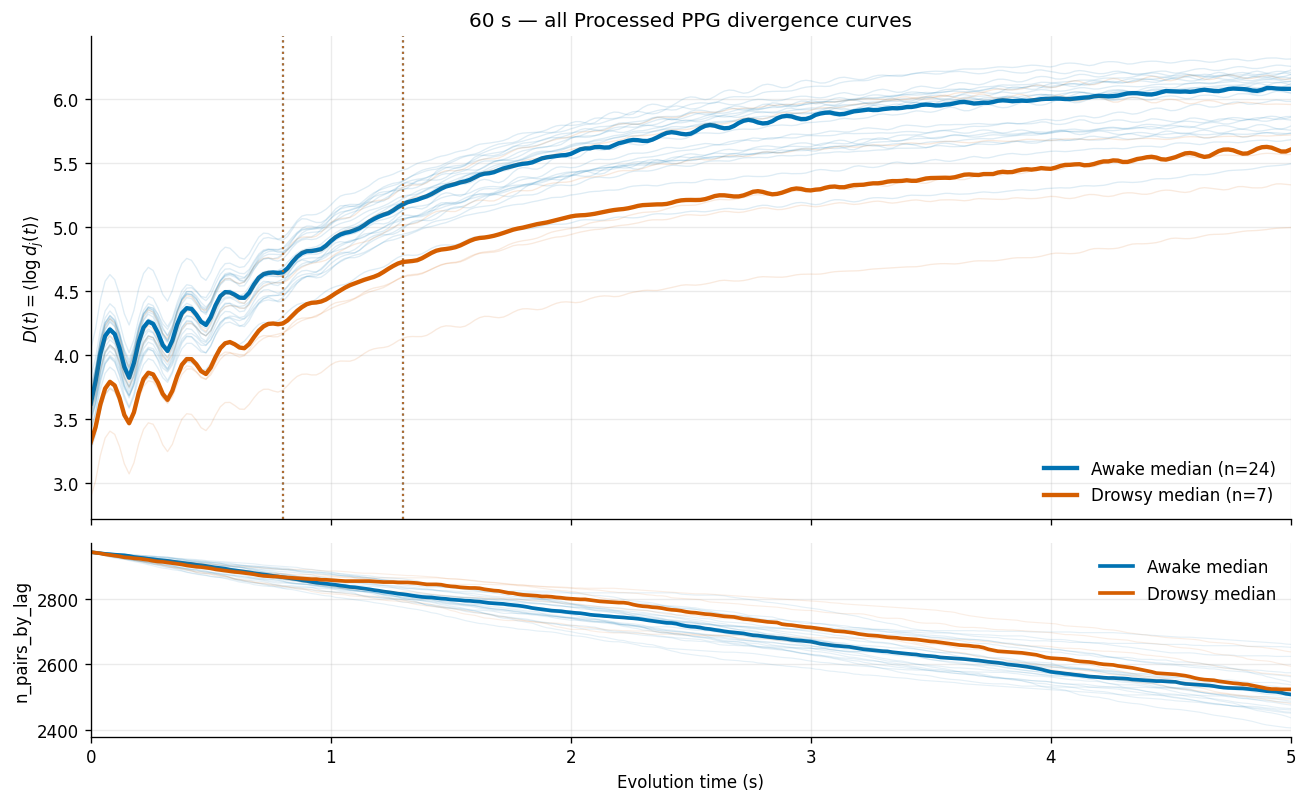

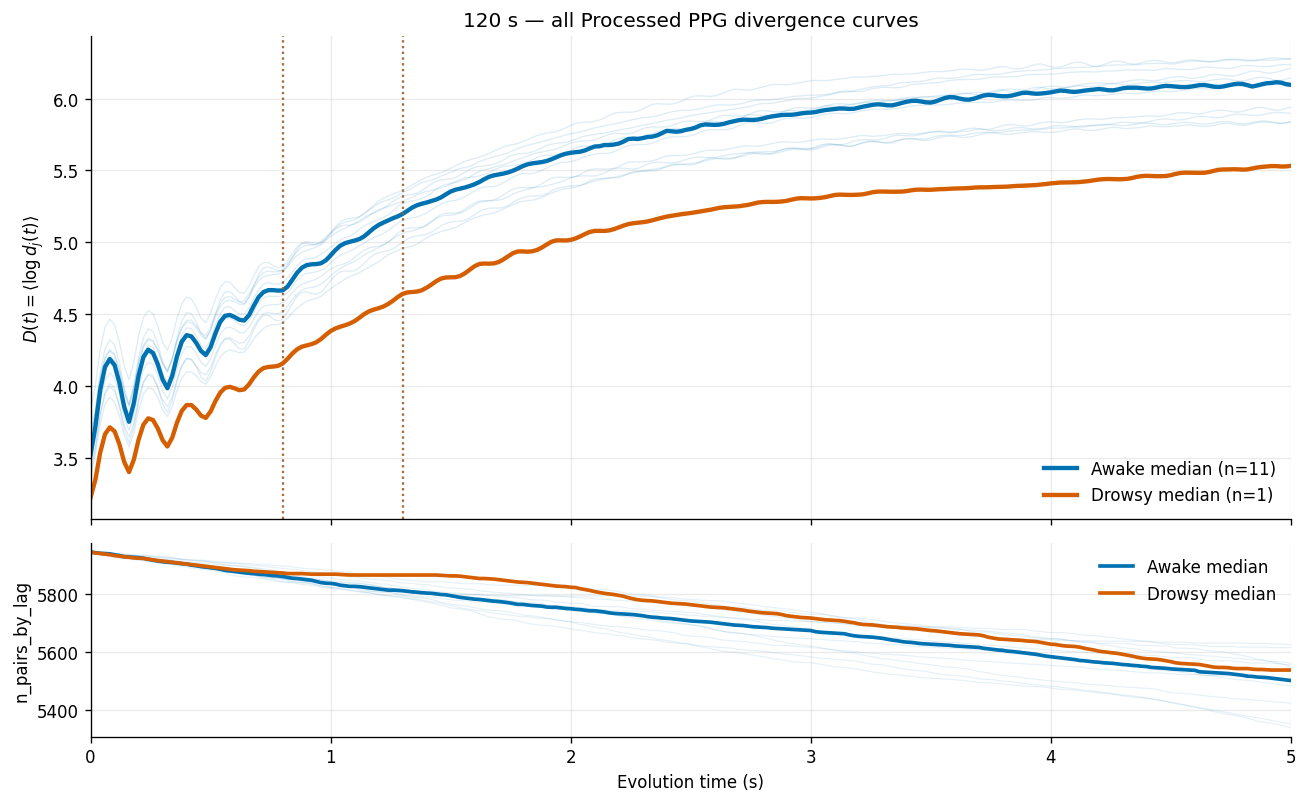

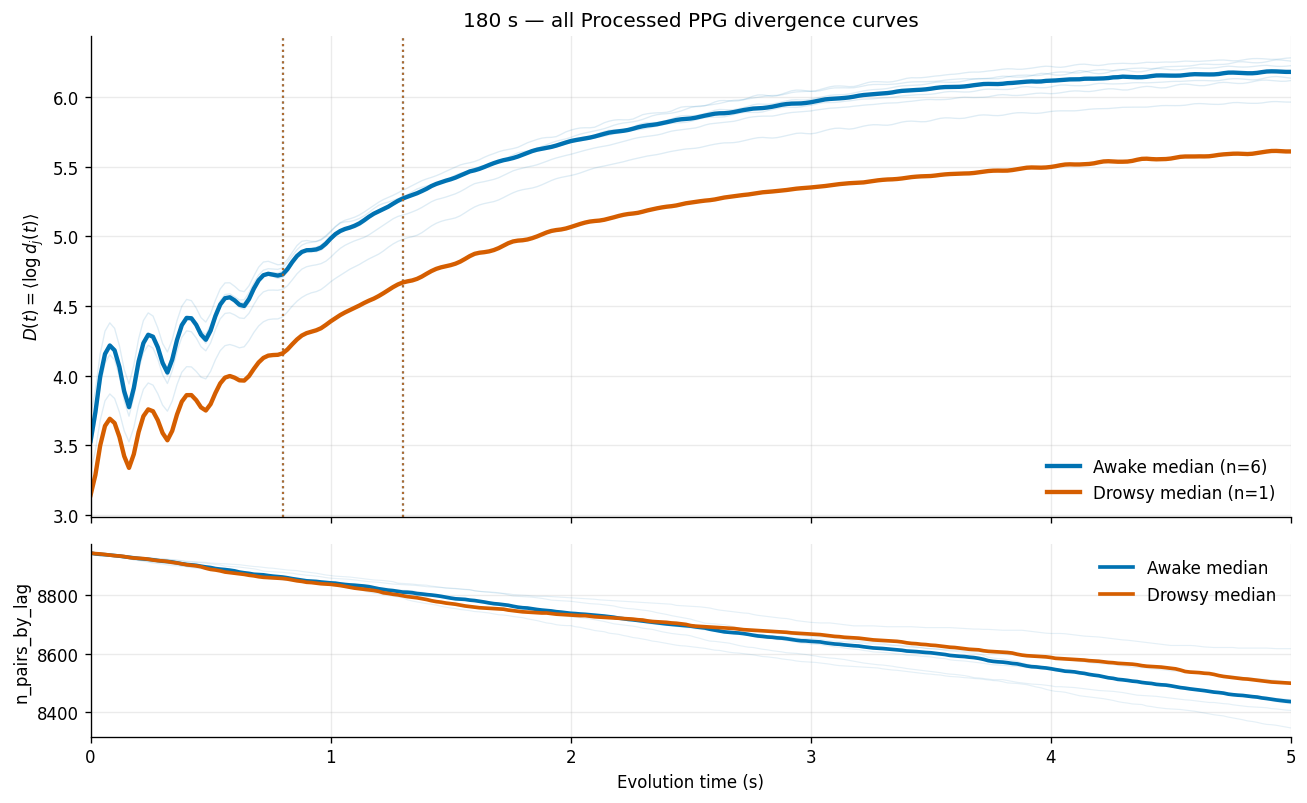

,duration_s,state,n_windows,theiler_median_s,theiler_min_s,theiler_max_s,pairs_initial_min,pairs_last_lag_min
0,60,Awake,24,0.56,0.50,0.62,2944,2405
1,60,Drowsy,7,0.58,0.54,0.62,2944,2479
2,120,Awake,11,0.56,0.54,0.62,5944,5339
3,120,Drowsy,1,0.58,0.58,0.58,5944,5538
4,180,Awake,6,0.56,0.54,0.62,8944,8346
5,180,Drowsy,1,0.58,0.58,0.58,8944,8499


In [13]:
# Cell 3 — Compute Divergence Curves for All Windows (no LLE fit)
def compute_divergence_only(signal, sampling_rate):
    """Run the frozen Rosenstein pipeline through divergence only."""
    if THEILER_RULE != "spectral_mean_period":
        raise ValueError(f"Unsupported frozen Theiler rule: {THEILER_RULE}")

    estimated_period_s = estimate_mean_period(signal, sampling_rate)
    theiler_samples = max(int(np.round(estimated_period_s * sampling_rate)), 1)
    states = reconstruct_phase_space(signal, m=M, tau_samples=TAU_SAMPLES)
    neighbors, initial_distances = find_nearest_neighbors(
        states, theiler_samples=theiler_samples
    )
    scale = max(np.std(states), 1.0)
    distance_tolerance = np.finfo(float).eps * scale * np.sqrt(M) * 10
    valid_initial = (
        (neighbors >= 0)
        & np.isfinite(initial_distances)
        & (initial_distances > distance_tolerance)
    )
    neighbors[~valid_initial] = -1
    max_lag_samples = min(
        int(np.floor(MAX_FOLLOW_S * sampling_rate)), len(states) - 1
    )
    mean_log_distance, n_pairs_by_lag = compute_divergence_curve(
        states,
        neighbors,
        max_lag_samples=max_lag_samples,
        distance_tolerance=distance_tolerance,
    )
    return {
        "time_s": np.arange(max_lag_samples + 1) / sampling_rate,
        "mean_log_distance": mean_log_distance,
        "n_pairs_by_lag": n_pairs_by_lag,
        "theiler_s": theiler_samples / sampling_rate,
        "theiler_samples": theiler_samples,
        "n_pairs_initial": int(np.sum(valid_initial)),
        "n_embedded": len(states),
    }


divergence_results = {
    key: compute_divergence_only(window["signal"], window["sampling_rate"])
    for key, window in analysis_windows.items()
}

for duration_s in WINDOW_DURATIONS_S:
    fig, (curve_ax, pairs_ax) = plt.subplots(
        2, 1, figsize=(11.0, 6.8), sharex=True,
        gridspec_kw={"height_ratios": [2.5, 1.0]},
    )
    for state in STATE_LABELS:
        group_keys = sorted(
            key for key in divergence_results
            if key[0] == duration_s and key[1] == state
        )
        group_curves = []
        group_pairs = []
        for key in group_keys:
            curve = divergence_results[key]
            group_curves.append(curve["mean_log_distance"])
            group_pairs.append(curve["n_pairs_by_lag"])
            curve_ax.plot(
                curve["time_s"], curve["mean_log_distance"],
                color=COLORS[state], alpha=0.13, linewidth=0.8,
            )
            pairs_ax.plot(
                curve["time_s"], curve["n_pairs_by_lag"],
                color=COLORS[state], alpha=0.10, linewidth=0.7,
            )

        time_axis = divergence_results[group_keys[0]]["time_s"]
        curve_ax.plot(
            time_axis, np.nanmedian(np.vstack(group_curves), axis=0),
            color=COLORS[state], linewidth=2.6,
            label=f"{state} median (n={len(group_keys)})",
        )
        pairs_ax.plot(
            time_axis, np.median(np.vstack(group_pairs), axis=0),
            color=COLORS[state], linewidth=2.2, label=f"{state} median",
        )
        start_s, end_s = FIT_REGIONS[(duration_s, state)]
        curve_ax.axvline(start_s, color=COLORS[state], linestyle=":", alpha=0.75)
        curve_ax.axvline(end_s, color=COLORS[state], linestyle=":", alpha=0.75)

    curve_ax.set(
        title=f"{duration_s} s — all Processed PPG divergence curves",
        ylabel=r"$D(t)=\langle \log d_j(t) \rangle$",
        xlim=(0.0, MAX_FOLLOW_S),
    )
    pairs_ax.set(xlabel="Evolution time (s)", ylabel="n_pairs_by_lag")
    curve_ax.legend(frameon=False)
    pairs_ax.legend(frameon=False)
    curve_ax.grid(alpha=0.25)
    pairs_ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

curve_rows = [
    {
        "duration_s": key[0],
        "state": key[1],
        "window_id": key[2],
        "theiler_s": curve["theiler_s"],
        "theiler_samples": curve["theiler_samples"],
        "n_embedded": curve["n_embedded"],
        "n_pairs_initial": curve["n_pairs_initial"],
        "n_pairs_last_lag": int(curve["n_pairs_by_lag"][-1]),
    }
    for key, curve in divergence_results.items()
]
curve_table = pd.DataFrame(curve_rows).sort_values(
    ["duration_s", "state", "window_id"]
)
curve_group_summary = (
    curve_table.groupby(["duration_s", "state"], as_index=False)
    .agg(
        n_windows=("window_id", "size"),
        theiler_median_s=("theiler_s", "median"),
        theiler_min_s=("theiler_s", "min"),
        theiler_max_s=("theiler_s", "max"),
        pairs_initial_min=("n_pairs_initial", "min"),
        pairs_last_lag_min=("n_pairs_last_lag", "min"),
    )
)
display(curve_group_summary.round(5))

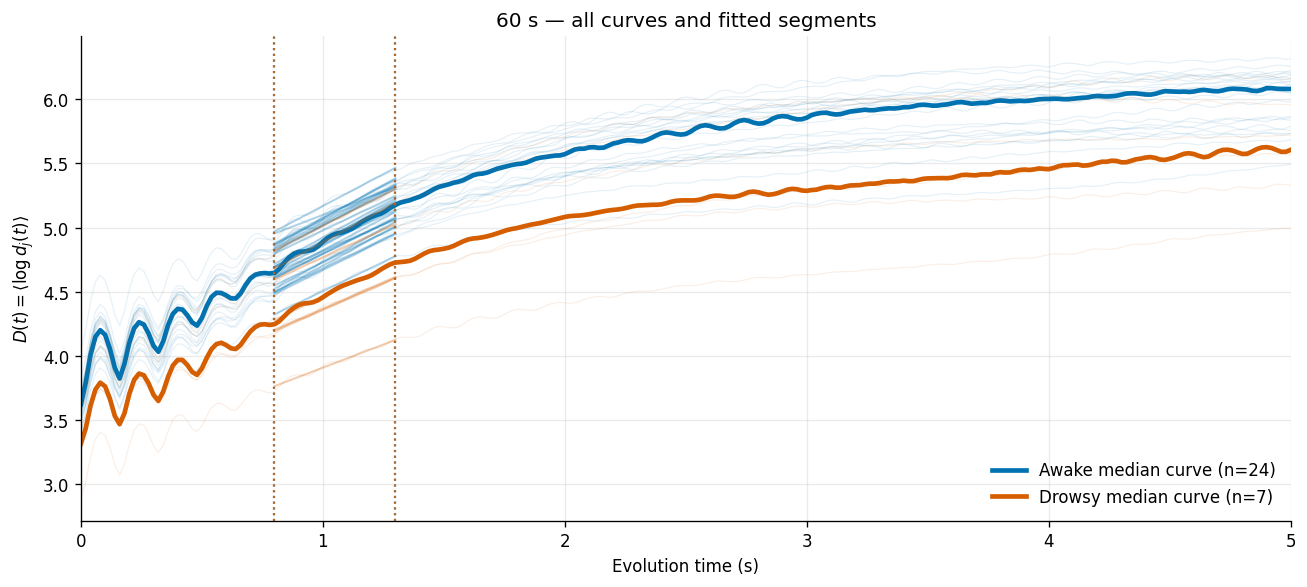

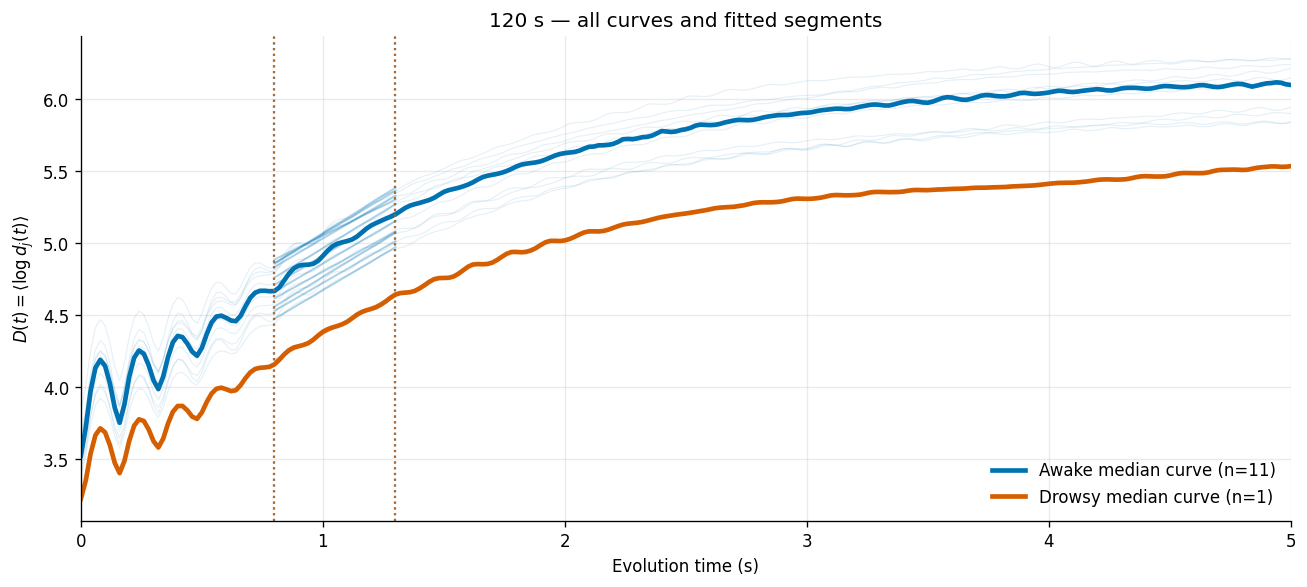

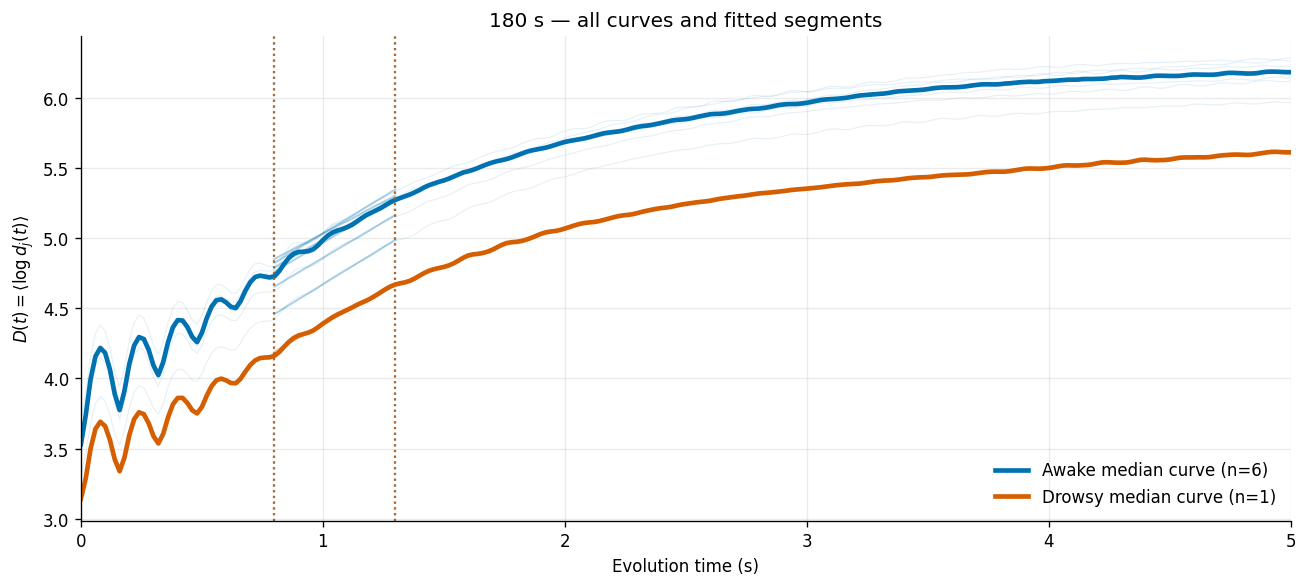

,duration_s,state,window_id,LLE_1_per_s,fit_start_s,fit_end_s,fit_duration_s,R2,Theiler_s,n_pairs_initial,n_pairs_fit_min,fit_sensitivity_max_relative_change,valid,qc_reason
0,60,Awake,1,0.93814,0.8,1.3,0.5,0.98683,0.56,2944,2816,0.05416,True,ok
1,60,Awake,2,0.99371,0.8,1.3,0.5,0.98763,0.56,2944,2829,0.03786,True,ok
2,60,Awake,3,1.00131,0.8,1.3,0.5,0.99447,0.54,2944,2849,0.03992,True,ok
3,60,Awake,4,1.00568,0.8,1.3,0.5,0.98793,0.54,2944,2775,0.04815,True,ok
4,60,Awake,5,1.02239,0.8,1.3,0.5,0.99413,0.54,2944,2835,0.02743,True,ok
5,60,Awake,6,0.99211,0.8,1.3,0.5,0.98140,0.60,2944,2815,0.05305,True,ok
6,60,Awake,7,0.89892,0.8,1.3,0.5,0.98656,0.58,2944,2813,0.05342,True,ok
7,60,Awake,8,0.72553,0.8,1.3,0.5,0.94142,0.52,2944,2844,0.03562,True,ok
8,60,Awake,9,0.96841,0.8,1.3,0.5,0.98428,0.54,2944,2798,0.05856,True,ok
9,60,Awake,10,1.04769,0.8,1.3,0.5,0.98992,0.56,2944,2806,0.03750,True,ok


,duration_s,state,n_windows,LLE_mean,LLE_sd,LLE_median,LLE_Q1,LLE_Q3,R2_median,R2_min,n_valid,n_pairs_fit_min,sensitivity_median,sensitivity_max
0,60,Awake,24,0.95380,0.07624,0.95505,0.91366,1.00489,0.98772,0.94142,24,2775,0.04584,0.06335
1,60,Drowsy,7,0.87435,0.09980,0.86481,0.82330,0.93164,0.98614,0.97153,7,2792,0.04793,0.05745
2,120,Awake,11,0.98219,0.05912,0.99290,0.97434,1.01439,0.98991,0.97166,11,5787,0.04650,0.05102
3,120,Drowsy,1,0.90165,NaN,0.90165,0.90165,0.90165,0.99378,0.99378,1,5865,0.04458,0.04458
4,180,Awake,6,1.00842,0.05672,1.02465,1.00176,1.04101,0.98955,0.97762,6,8791,0.04110,0.04616
5,180,Drowsy,1,0.96871,NaN,0.96871,0.96871,0.96871,0.99448,0.99448,1,8798,0.04746,0.04746


,duration_s,median_LLE_Awake,median_LLE_Drowsy,Delta_median_LLE_Drowsy_minus_Awake
0,60,0.95505,0.86481,-0.09024
1,120,0.99290,0.90165,-0.09125
2,180,1.02465,0.96871,-0.05594


,duration_s,state,qc_reason,n_windows
0,60,Awake,ok,24
1,60,Drowsy,ok,7
2,120,Awake,ok,11
3,120,Drowsy,ok,1
4,180,Awake,ok,6
5,180,Drowsy,ok,1


In [14]:
# Cell 4 — Fit Every Window + Descriptive Results
def slope_from_existing_curve(curve, start_s, end_s):
    """Fit one interval without recomputing the divergence curve."""
    mask = (
        (curve["time_s"] >= start_s)
        & (curve["time_s"] <= end_s)
        & np.isfinite(curve["mean_log_distance"])
        & (curve["n_pairs_by_lag"] >= MIN_FIT_PAIRS)
    )
    if np.count_nonzero(mask) < 3:
        return np.nan
    return float(linregress(
        curve["time_s"][mask], curve["mean_log_distance"][mask]
    ).slope)


lle_results = {}
result_rows = []
for key, window in analysis_windows.items():
    duration_s, state, window_id = key
    fit_start_s, fit_end_s = FIT_REGIONS[(duration_s, state)]
    result = compute_rosenstein_lle(
        window["signal"],
        sampling_rate=FS,
        m=M,
        tau_samples=TAU_SAMPLES,
        fit_start_s=fit_start_s,
        fit_end_s=fit_end_s,
        max_follow_s=MAX_FOLLOW_S,
        theiler_s=THEILER_S,
        min_initial_pairs=MIN_INITIAL_PAIRS,
        min_fit_pairs=MIN_FIT_PAIRS,
        min_r2=MIN_R2,
    )
    lle_results[key] = result
    curve = divergence_results[key]
    assert np.allclose(result.time_s, curve["time_s"])
    assert np.allclose(
        result.mean_log_distance, curve["mean_log_distance"], equal_nan=True
    )
    assert np.array_equal(result.n_pairs_by_lag, curve["n_pairs_by_lag"])

    sensitivity_regions = (
        (max(0.0, fit_start_s - FIT_SENSITIVITY_SHIFT_S), fit_end_s),
        (fit_start_s + FIT_SENSITIVITY_SHIFT_S, fit_end_s),
        (fit_start_s, fit_end_s - FIT_SENSITIVITY_SHIFT_S),
        (fit_start_s, min(MAX_FOLLOW_S, fit_end_s + FIT_SENSITIVITY_SHIFT_S)),
    )
    sensitivity_lles = np.array([
        slope_from_existing_curve(curve, start_s, end_s)
        for start_s, end_s in sensitivity_regions
    ])
    finite_sensitivity = sensitivity_lles[np.isfinite(sensitivity_lles)]
    max_relative_change = (
        np.max(np.abs(finite_sensitivity - result.lle)) / abs(result.lle)
        if finite_sensitivity.size and np.isfinite(result.lle) and result.lle != 0.0
        else np.nan
    )
    result_rows.append({
        "duration_s": duration_s,
        "state": state,
        "window_id": window_id,
        "LLE_1_per_s": result.lle,
        "fit_start_s": result.fit_start_s,
        "fit_end_s": result.fit_end_s,
        "fit_duration_s": result.fit_end_s - result.fit_start_s,
        "R2": result.fit_r2,
        "Theiler_s": result.theiler_s,
        "n_pairs_initial": result.n_pairs_initial,
        "n_pairs_fit_min": result.n_pairs_fit_min,
        "fit_sensitivity_max_relative_change": max_relative_change,
        "valid": result.valid,
        "qc_reason": result.qc_reason,
    })

results_table = pd.DataFrame(result_rows).sort_values(
    ["duration_s", "state", "window_id"]
).reset_index(drop=True)
assert len(results_table) == len(analysis_windows)

for duration_s in WINDOW_DURATIONS_S:
    fig, ax = plt.subplots(figsize=(11.0, 5.0))
    for state in STATE_LABELS:
        group_keys = sorted(
            key for key in lle_results
            if key[0] == duration_s and key[1] == state
        )
        group_curves = []
        for position, key in enumerate(group_keys):
            result = lle_results[key]
            start_s, end_s = FIT_REGIONS[(duration_s, state)]
            fit_mask = (
                (result.time_s >= start_s)
                & (result.time_s <= end_s)
                & np.isfinite(result.mean_log_distance)
                & (result.n_pairs_by_lag >= MIN_FIT_PAIRS)
            )
            group_curves.append(result.mean_log_distance)
            ax.plot(
                result.time_s, result.mean_log_distance,
                color=COLORS[state], alpha=0.10, linewidth=0.7,
            )
            if np.isfinite(result.lle) and np.count_nonzero(fit_mask) >= 3:
                fit_time = result.time_s[fit_mask]
                intercept = np.mean(
                    result.mean_log_distance[fit_mask] - result.lle * fit_time
                )
                ax.plot(
                    fit_time, intercept + result.lle * fit_time,
                    color=COLORS[state], alpha=0.32, linewidth=1.2,
                )

        time_axis = lle_results[group_keys[0]].time_s
        ax.plot(
            time_axis, np.nanmedian(np.vstack(group_curves), axis=0),
            color=COLORS[state], linewidth=2.8,
            label=f"{state} median curve (n={len(group_keys)})",
        )
        start_s, end_s = FIT_REGIONS[(duration_s, state)]
        ax.axvline(start_s, color=COLORS[state], linestyle=":", alpha=0.8)
        ax.axvline(end_s, color=COLORS[state], linestyle=":", alpha=0.8)

    ax.set(
        title=f"{duration_s} s — all curves and fitted segments",
        xlabel="Evolution time (s)",
        ylabel=r"$D(t)=\langle \log d_j(t) \rangle$",
        xlim=(0.0, MAX_FOLLOW_S),
    )
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

def q1(values):
    return values.quantile(0.25)


def q3(values):
    return values.quantile(0.75)


group_summary = (
    results_table.groupby(["duration_s", "state"], as_index=False)
    .agg(
        n_windows=("window_id", "size"),
        LLE_mean=("LLE_1_per_s", "mean"),
        LLE_sd=("LLE_1_per_s", "std"),
        LLE_median=("LLE_1_per_s", "median"),
        LLE_Q1=("LLE_1_per_s", q1),
        LLE_Q3=("LLE_1_per_s", q3),
        R2_median=("R2", "median"),
        R2_min=("R2", "min"),
        n_valid=("valid", "sum"),
        n_pairs_fit_min=("n_pairs_fit_min", "min"),
        sensitivity_median=("fit_sensitivity_max_relative_change", "median"),
        sensitivity_max=("fit_sensitivity_max_relative_change", "max"),
    )
)
lle_medians = group_summary.pivot(
    index="duration_s", columns="state", values="LLE_median"
)
delta_table = pd.DataFrame({
    "duration_s": lle_medians.index,
    "median_LLE_Awake": lle_medians["Awake"].to_numpy(),
    "median_LLE_Drowsy": lle_medians["Drowsy"].to_numpy(),
    "Delta_median_LLE_Drowsy_minus_Awake": (
        lle_medians["Drowsy"] - lle_medians["Awake"]
    ).to_numpy(),
})
qc_summary = (
    results_table.groupby(["duration_s", "state", "qc_reason"], as_index=False)
    .size()
    .rename(columns={"size": "n_windows"})
)

display(results_table.round(5))
display(group_summary.round(5))
display(delta_table.round(5))
display(qc_summary)

# Rosenstein LLE — Session 1 All-Window Development Report

## Configuration and cohort

- Session: 1; representation: Processed PPG only
- `m = 8`, `tau = 0.16 s = 8 samples`, `fs = 50 Hz`
- Theiler rule: spectral mean period, estimated independently per window
- Candidate fit region: `0.80–1.30 s`; LLE unit: `1/s`
- Included cohort: every Processed window with `analysis_included=True`
- Total: **50 windows** — 31 at 60 s, 12 at 120 s, and 7 at 180 s

| Duration | Awake n | Drowsy n |
|---|---:|---:|
| 60 s | 24 | 7 |
| 120 s | 11 | 1 |
| 180 s | 6 | 1 |

## Descriptive results

Values below are group medians; delta is `median(Drowsy) − median(Awake)`.

| Duration | Awake median LLE | Drowsy median LLE | Delta median | Awake median R² | Drowsy median R² | QC |
|---|---:|---:|---:|---:|---:|---|
| 60 s | 0.9551 | 0.8648 | −0.0902 | 0.9877 | 0.9861 | 31/31 `ok` |
| 120 s | 0.9929 | 0.9017 | −0.0912 | 0.9899 | 0.9938 | 12/12 `ok` |
| 180 s | 1.0247 | 0.9687 | −0.0559 | 0.9896 | 0.9945 | 7/7 `ok` |

Awake LLE IQRs were `0.9137–1.0049`, `0.9743–1.0144`, and `1.0018–1.0410 1/s` for 60/120/180 s. The corresponding 60-s Drowsy IQR was `0.8233–0.9316 1/s`; IQR is not informative for the single Drowsy window at 120 and 180 s.

## Divergence and QC observations

- Individual and median divergence curves retain the early oscillatory transient, a common near-linear interval, and gradual late-lag flattening.
- All **50/50** fits pass QC. The lowest observed R² is `0.9414`, above the frozen threshold `0.90`.
- Minimum pair support inside the fit is `2775`, `5787`, and `8791` for 60/120/180-s groups, far above `min_fit_pairs=30`.
- Theiler windows range from `0.50–0.62 s`, with group medians near `0.56–0.58 s`.
- A `±0.10 s` boundary perturbation changes LLE by at most `6.34%`; median sensitivity is approximately `4–5%`.

## Interpretation

- Median Drowsy LLE is lower than median Awake LLE at all three durations in this Session 1 cohort.
- This is descriptive only. Drowsy support is highly imbalanced and contains only one window at 120 s and one at 180 s, so no population or state inference is justified.
- Positive LLE alone is not evidence that Processed PPG is deterministic chaos.

## Development conclusion

- Rosenstein core on all included Session 1 Processed windows: **PASS** for computational feasibility and numerical QC.
- The common `0.80–1.30 s` region is locally stable for this session, but the fitting strategy should be frozen prospectively before cross-session analysis.
- Next step: `freeze fitting strategy → run the full Processed PPG dataset`.